In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv('Salary_Data.csv')

In [6]:
df.sample(5)

,YearsExperience,Salary
26,9.5,116969.0
12,4.0,56957.0
8,3.2,64445.0
10,3.9,63218.0
11,4.0,55794.0


In [7]:
df.shape

(30, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [9]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


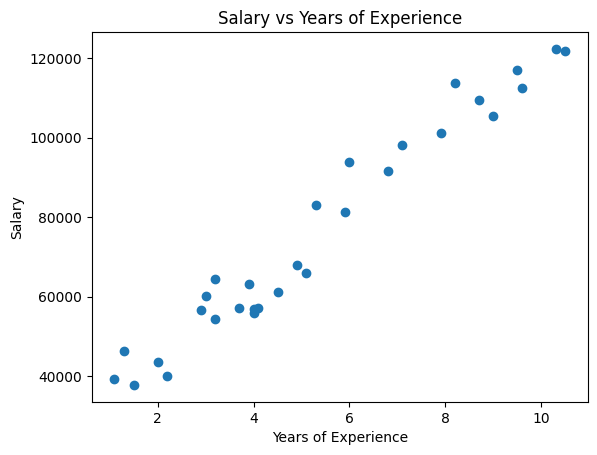

In [10]:
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [11]:
x_train, x_test, y_train, y_test = train_test_split(df[['YearsExperience']], df['Salary'], test_size=0.2, random_state=42)

In [12]:
lr = LinearRegression()

In [13]:
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Print the intercept of the linear regression model
# Intercept is the value of the dependent variable (Salary) when the independent variable (Years of Experience) is zero. It represents the starting point of the regression line on the y-axis.
print("Intercept:", lr.intercept_)

Intercept: 25321.583011776813


In [ ]:
# Print the coefficient of the linear regression model
# Coefficient represents the change in the dependent variable (Salary) for a one-unit change in
print("Coefficient:", lr.coef_[0])

Coefficient: 9423.815323030976


In [16]:
y_pred = lr.predict(x_test)

In [17]:
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

In [ ]:
# Compare the actual and predicted salaries
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

comparison.head(10)

,Actual Salary,Predicted Salary
0,112635.0,115790.210113
1,67938.0,71498.278095
2,113812.0,102596.868661
3,83088.0,75267.804224
4,64445.0,55477.792045
5,57189.0,60189.699707


In [ ]:
# Model Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 6286.453830757749
MSE : 49830096.85590839
RMSE: 7059.04362190151
R²  : 0.9024461774180497


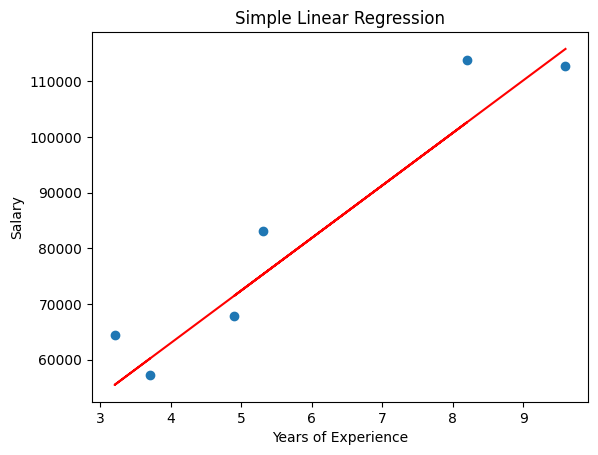

In [ ]:
# Visualizing the results
plt.scatter(x_test, y_test)


plt.plot(
    x_test,
    y_pred , color='red'
)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Simple Linear Regression")

plt.show()

## Predict Salary for New Experience

In [25]:
experience = [[5]]

predicted_salary = lr.predict(experience)

print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 72440.6596269317


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
experience = [[10]]

predicted_salary = lr.predict(experience)

print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 119559.73624208657


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Saving the model 

In [27]:
import joblib

joblib.dump(lr, "salary_model.pkl")

['salary_model.pkl']